In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from utilsforecast.plotting import plot_series
import tsfeatures as tsf
from sklearn.decomposition import PCA
from cycler import cycler
from sklearn.neighbors import LocalOutlierFactor
from  sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#D55F03", "#569CC6", "#13A076", "#CC79A7"])

In [2]:
aus_tourism=pd.read_csv("data/aus_tourism.csv",parse_dates=['ds'])
summary_stats=tsf.tsfeatures(aus_tourism,freq=4,features=[tsf.statistics],scale=False)
summary_stats.head()

,unique_id,total_sum,mean,variance,median,p2point5,p5,p25,p75,p95,p97point5,max,min
0,Adelaide Hills-South Australia-Business,213.138886,2.664236,18.459768,1.255434,0.000000,0.000000,0.000000,3.920368,7.494302,14.725416,28.601515,0.000000
1,Adelaide Hills-South Australia-Holiday,837.382088,10.467276,40.554956,8.515966,2.074420,2.764184,5.767673,14.059997,22.155028,23.982903,35.751337,0.000000
2,Adelaide Hills-South Australia-Other,112.394454,1.404931,2.725473,0.907595,0.000000,0.000000,0.000000,2.093167,4.375983,5.259445,8.953163,0.000000
3,Adelaide Hills-South Australia-Visiting,1136.202374,14.202530,114.115762,12.206619,2.148497,2.363034,8.907923,16.806339,29.007576,36.739604,81.102109,0.777638
4,Adelaide-South Australia-Business,12442.232789,155.527910,1270.667509,152.576618,99.956245,101.623513,133.893462,176.935536,229.833803,237.917489,242.494368,68.725393


In [3]:
#shows us the trends and signals of the data by checking out Autocorrelation.
acf_feat=tsf.tsfeatures(aus_tourism,freq=4,features=[tsf.acf_features])
acf_feat.head(10)


,unique_id,x_acf1,x_acf10,diff1_acf1,diff1_acf10,diff2_acf1,diff2_acf10,seas_acf1
0,Adelaide Hills-South Australia-Business,0.070915,0.134473,-0.579504,0.414537,-0.750404,0.746004,-0.062808
1,Adelaide Hills-South Australia-Holiday,0.131320,0.312710,-0.536153,0.500211,-0.716343,0.906314,0.208042
2,Adelaide Hills-South Australia-Other,0.261143,0.330169,-0.253227,0.317087,-0.457470,0.392235,0.074534
3,Adelaide Hills-South Australia-Visiting,0.139167,0.116787,-0.472006,0.238615,-0.625575,0.407713,0.169772
4,Adelaide-South Australia-Business,0.033271,0.130646,-0.519622,0.462537,-0.676429,0.741357,0.200875
5,Adelaide-South Australia-Holiday,0.045570,0.371898,-0.342625,0.614365,-0.486833,0.558244,0.351151
6,Adelaide-South Australia-Other,0.516806,1.153598,-0.408620,0.382891,-0.675120,0.792353,0.341781
7,Adelaide-South Australia-Visiting,0.068365,0.294237,-0.393654,0.452291,-0.517959,0.447296,0.344930
8,Alice Springs-Northern Territory-Business,0.217424,0.366634,-0.499585,0.380557,-0.657996,0.587038,0.315314
9,Alice Springs-Northern Territory-Holiday,-0.006605,2.113374,-0.152790,2.113436,-0.274286,1.550737,0.728589


In [4]:
stl_feat=tsf.tsfeatures(aus_tourism,freq=4,features=[tsf.stl_features])
stl_feat.head(10).iloc[:,:5]

,unique_id,nperiods,seasonal_period,trend,spike
0,Adelaide Hills-South Australia-Business,1,4,0.459551,0.000322
1,Adelaide Hills-South Australia-Holiday,1,4,0.531073,0.000105
2,Adelaide Hills-South Australia-Other,1,4,0.589967,0.000053
3,Adelaide Hills-South Australia-Visiting,1,4,0.487016,0.000580
4,Adelaide-South Australia-Business,1,4,0.461801,0.000097
5,Adelaide-South Australia-Holiday,1,4,0.577813,0.000017
6,Adelaide-South Australia-Other,1,4,0.746461,0.000024
7,Adelaide-South Australia-Visiting,1,4,0.448953,0.000048
8,Alice Springs-Northern Territory-Business,1,4,0.551599,0.000052
9,Alice Springs-Northern Territory-Holiday,1,4,0.379298,0.000007


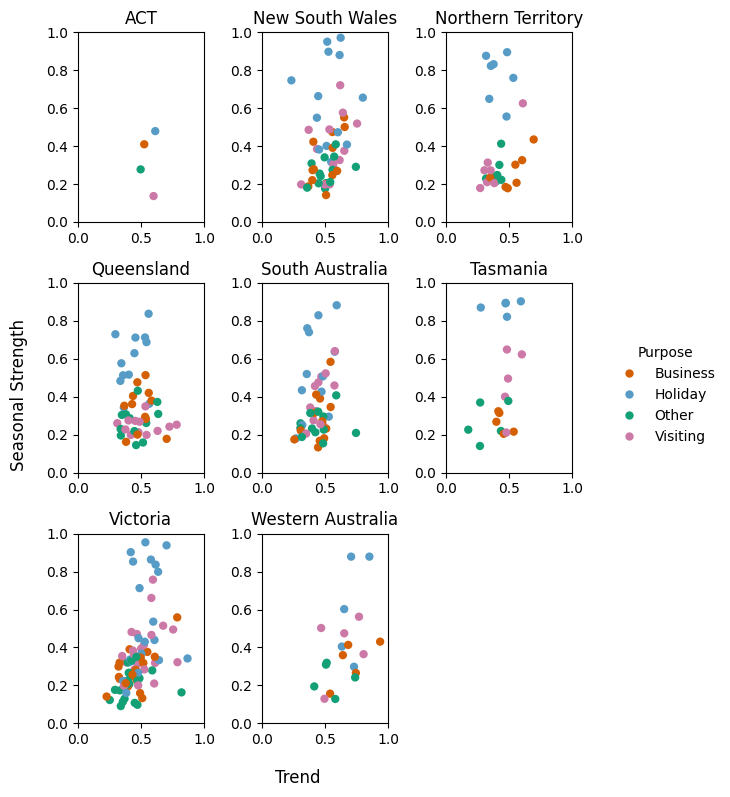

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

df=(
    stl_feat['unique_id'].str.split("-",expand=True)
    .rename(columns={0:"region",1:"state",2:"purpose"})
    .join(stl_feat)
)
fig,axs=plt.subplots(3,3,figsize=(6,8))
axs=axs.flatten()
for ax, (state,state_df) in zip(axs,df.groupby('state')):
    sns.scatterplot(x="trend",y="seasonal_strength",hue="purpose",edgecolor="none",data=state_df,ax=ax)
    ax.get_legend().remove()
    ax.set(title=state,xlabel="",ylabel="",xlim=(0,1),ylim=(0,1))
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels,
    title="Purpose", loc="center left", frameon=False,
    bbox_to_anchor=(1.02, .5), borderaxespad=0)
fig.supxlabel('Trend')
fig.supylabel('Seasonal Strength')

for ax in axs:
    if not ax.lines:
        ax.set_visible(False)
plt.tight_layout()


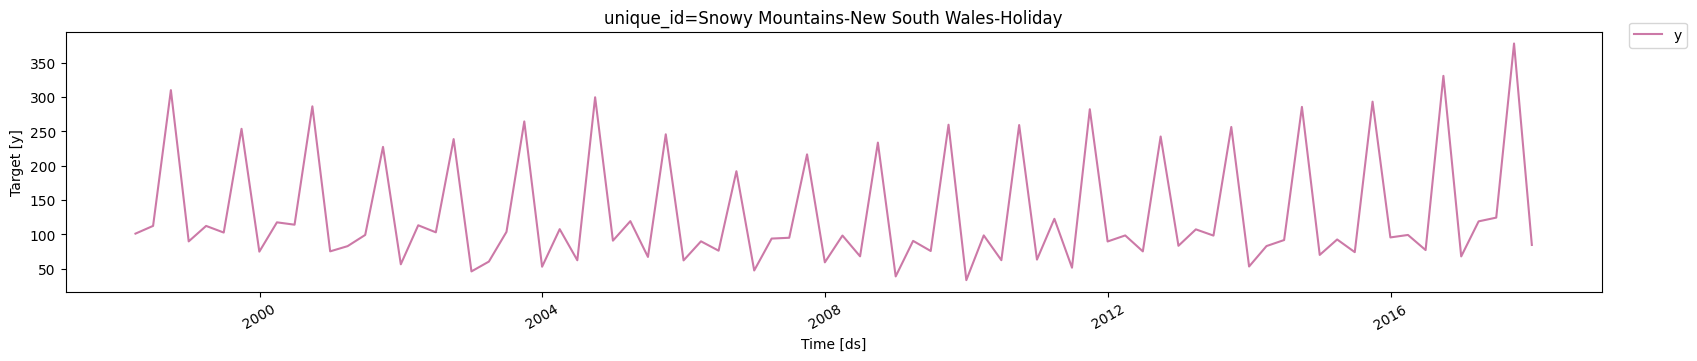

In [6]:
from utilsforecast.plotting import plot_series
row=stl_feat.loc[lambda x:x['seasonal_strength'].idxmax()]
plot_series(aus_tourism,ids=[row["unique_id"]])

In [7]:
#all feature of the Ts Features
all_features = [
    tsf.acf_features,
    tsf.arch_stat,
    tsf.crossing_points,
    tsf.entropy,
    tsf.flat_spots,
    tsf.heterogeneity,
    tsf.holt_parameters,
    tsf.lumpiness,
    tsf.nonlinearity,
    tsf.pacf_features,
    tsf.stl_features,
    tsf.stability,
    tsf.hw_parameters,
    tsf.unitroot_kpss,
    tsf.unitroot_pp,
    tsf.series_length,
    tsf.hurst,
]
all_feat = tsf.tsfeatures(aus_tourism, freq=4, features=all_features)
all_feat.head(10)

,unique_id,hurst,series_length,unitroot_pp,unitroot_kpss,hw_alpha,hw_beta,hw_gamma,stability,nperiods,...,entropy,crossing_points,arch_lm,x_acf1,x_acf10,diff1_acf1,diff1_acf10,diff2_acf1,diff2_acf10,seas_acf1
0,Adelaide Hills-South Australia-Business,NaN,80,-80.527131,0.059545,1.490116e-08,1.219903e-08,0.000000,0.293653,1,...,0.894660,36,0.014362,0.070915,0.134473,-0.579504,0.414537,-0.750404,0.746004,-0.062808
1,Adelaide Hills-South Australia-Holiday,0.822970,80,-74.302188,0.476403,9.899147e-02,9.899147e-02,0.000000,0.408978,1,...,0.830890,33,0.120527,0.131320,0.312710,-0.536153,0.500211,-0.716343,0.906314,0.208042
2,Adelaide Hills-South Australia-Other,0.599001,80,-55.384688,0.604552,1.490116e-08,1.480779e-08,0.179857,0.273886,1,...,0.862339,37,0.265443,0.261143,0.330169,-0.253227,0.317087,-0.457470,0.392235,0.074534
3,Adelaide Hills-South Australia-Visiting,0.756890,80,-71.076026,0.749431,1.490116e-08,1.150051e-09,0.000000,0.333059,1,...,0.907152,25,0.004941,0.139167,0.116787,-0.472006,0.238615,-0.625575,0.407713,0.169772
4,Adelaide-South Australia-Business,0.839906,80,-78.764248,0.220978,1.305853e-01,1.305853e-01,0.000000,0.317769,1,...,0.848084,43,0.182907,0.033271,0.130646,-0.519622,0.462537,-0.676429,0.741357,0.200875
5,Adelaide-South Australia-Holiday,0.708848,80,-72.567094,0.448565,1.758048e-01,1.758048e-01,0.000000,0.312279,1,...,0.736811,36,0.161045,0.045570,0.371898,-0.342625,0.614365,-0.486833,0.558244,0.351151
6,Adelaide-South Australia-Other,0.776053,80,-36.405038,1.406211,1.068326e-01,7.714895e-02,0.000000,0.573715,1,...,0.755293,28,0.455923,0.516806,1.153598,-0.408620,0.382891,-0.675120,0.792353,0.341781
7,Adelaide-South Australia-Visiting,0.737366,80,-74.136566,0.263653,1.629560e-01,0.000000e+00,0.000000,0.267454,1,...,0.775936,42,0.173340,0.068365,0.294237,-0.393654,0.452291,-0.517959,0.447296,0.344930
8,Alice Springs-Northern Territory-Business,0.672664,80,-65.844696,0.806786,1.456158e-01,0.000000e+00,0.000000,0.439484,1,...,0.850637,33,0.424878,0.217424,0.366634,-0.499585,0.380557,-0.657996,0.587038,0.315314
9,Alice Springs-Northern Territory-Holiday,0.578587,80,-54.381905,0.387297,1.490116e-08,7.912446e-09,0.000000,0.083596,1,...,0.412425,40,0.304123,-0.006605,2.113374,-0.152790,2.113436,-0.274286,1.550737,0.728589


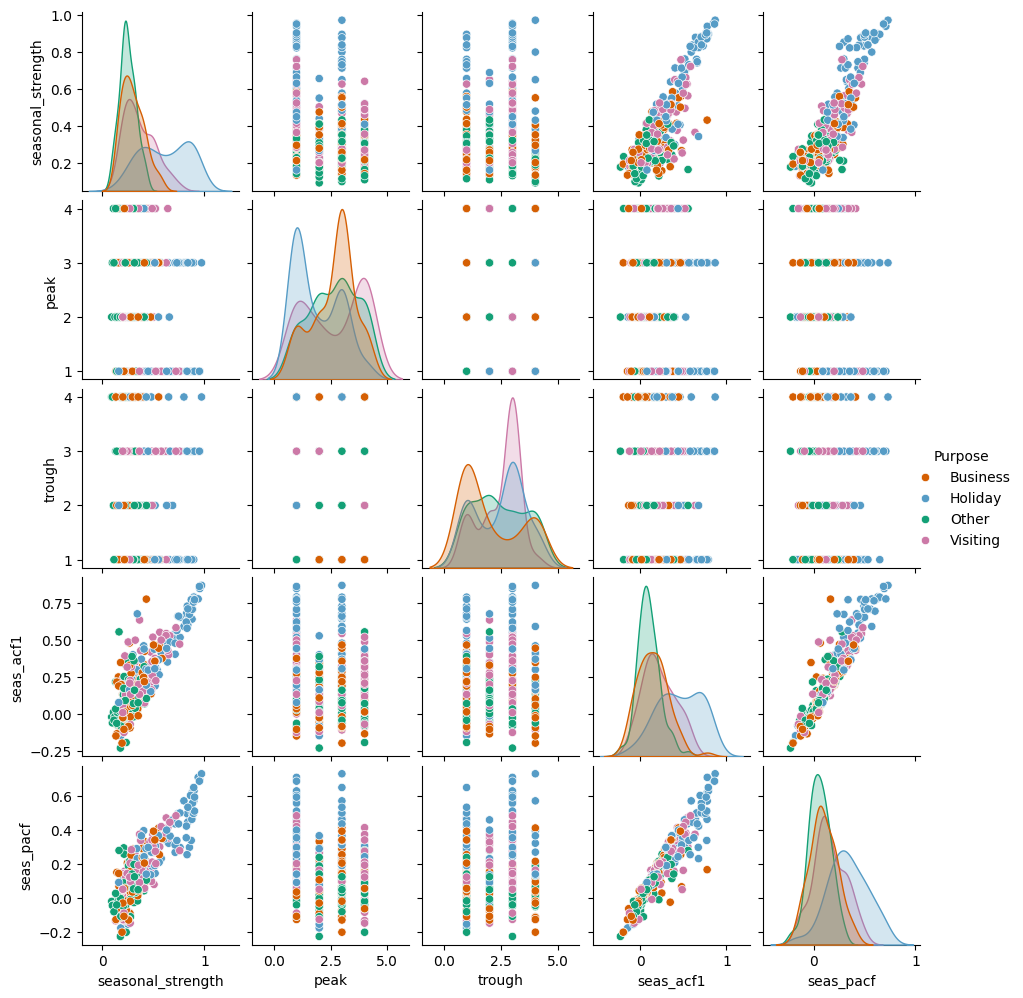

In [8]:
# we can see the relation ship between the season_acf1 and season_pacf with the seasonality strength and some peak and trough properties
seasonal_feat=all_feat[["unique_id","seasonal_strength","peak","trough","seas_acf1","seas_pacf"]]
df=(seasonal_feat['unique_id'].str.split("-",expand=True).rename(columns={0:"region",1:"state",2:"Purpose"}).join(seasonal_feat))
g=sns.pairplot(df,hue="Purpose")
g.figure.set_size_inches(10,10)
plt.show()

In [ ]:
#For us to deal with many variables we need a princple component by decreasing the dimensions.
df=(all_feat.assign(purpose=lambda x:x["unique_id"].str.split("-").str[-1])
    .dropna(axis="columns"))
X=df.drop(columns=["unique_id","purpose"])
pipeline=Pipeline([('scale',StandardScaler()),('pca',PCA(n_components=2)),])
principal_components=pipeline.fit_transform(X)
pca_df=(pd.DataFrame(data=principal_components,columns=['PC1','PC2']).join(df[['unique_id','purpose']]))



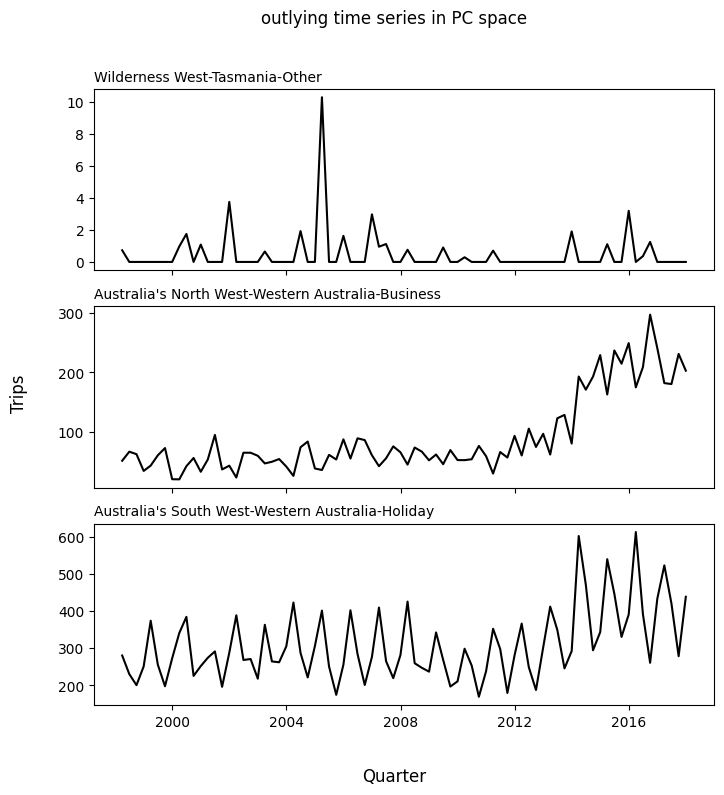

In [15]:
lof= LocalOutlierFactor(n_neighbors=10).fit(pca_df[['PC1','PC2']])
res=pca_df.assign(score=lof.negative_outlier_factor_)
selected_ids=res.sort_values("score")['unique_id'].head(3)
fig,axs=plt.subplots(3,figsize=(8,8),sharex=True)
for (ax,unique_id) in zip(axs,selected_ids):
    df=aus_tourism.loc[lambda x:x['unique_id']==unique_id]
    ax.plot(df['ds'],df['y'],color="k")
    ax.set_title(unique_id,loc="left",size="medium")
fig.suptitle("outlying time series in PC space")
fig.supylabel("Trips")
fig.supxlabel("Quarter")
plt.show()